<a href="https://colab.research.google.com/github/Gitika-26/Network-Analysis-and-Optimization-of-Power-Grid-Network/blob/main/Power_Grids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Network Analysis of Power Grids Against Targeted Attacks**

### *Importing Necessary Libraries*

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/ampl/mo-book.ampl.com/dev/notebooks/04/"
edges_url = base_url + "edges.csv"
edges_df = pd.read_csv(edges_url)
G = nx.from_pandas_edgelist(edges_df, source='node_id1', target='node_id2')
print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


### *Importing the Dataset*

In [2]:
base_url = "https://raw.githubusercontent.com/ampl/mo-book.ampl.com/dev/notebooks/04/"
edges_url = base_url + "edges.csv"
edges_df = pd.read_csv(edges_url)
G = nx.from_pandas_edgelist(edges_df, source='node_id1', target='node_id2')
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


### *Visualising the Network*

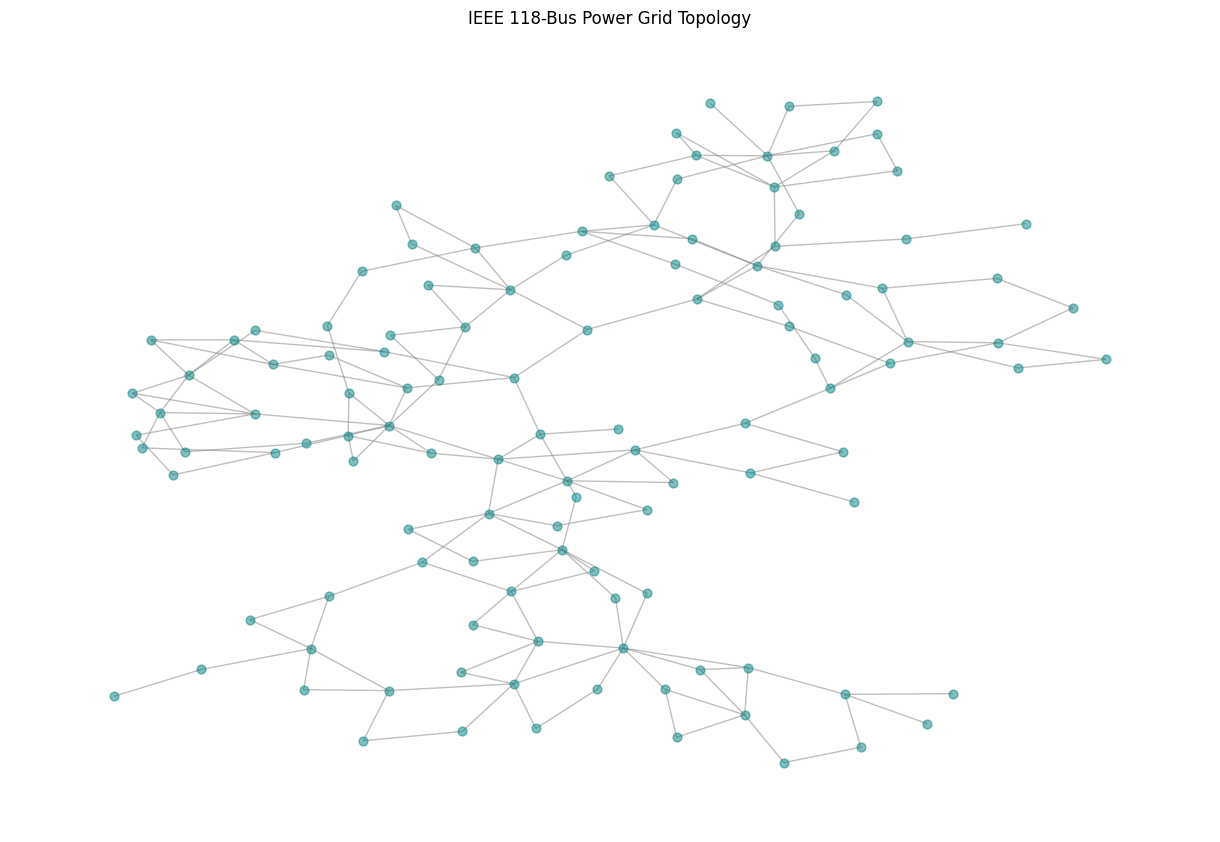

In [3]:
plt.figure(figsize=(12, 8))
pos = nx.kamada_kawai_layout(G) # Better layout for power grids
nx.draw(G, pos, node_size=40, node_color='teal', edge_color='gray', alpha=0.5)
plt.title("IEEE 118-Bus Power Grid Topology")
plt.show()


## *Analysing the Structure of the Network*

#### **Nodes, Edges & Density of the Network**

In [4]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

print(f"Nodes: {n_nodes}")
print(f"Edges: {n_edges}")
print(f"Density: {density:.4f}")

Nodes: 118
Edges: 179
Density: 0.0259


#### **Average Clustering Coefficient - In power grids, this is often low because grids are sparse.**
#### **Transitivity is Global Clustering Coeffecient**

In [5]:
avg_clustering = nx.average_clustering(G)
transitivity = nx.transitivity(G)
print(f"Average Clustering: {avg_clustering:.4f}")
print(f"Transitivity: {transitivity:.4f}")

Average Clustering: 0.1651
Transitivity: 0.1356


#### **Components in the power grid**

In [6]:
# Check if the grid is connected
is_connected = nx.is_connected(G)

if is_connected:
    diameter = nx.diameter(G)
    avg_path_length = nx.average_shortest_path_length(G)
    print(f"Diameter: {diameter}")
    print(f"Average Path Length: {avg_path_length:.4f}")
else:
    lcc = max(nx.connected_components(G), key=len)
    print(f"Graph is disconnected. LCC contains {len(lcc)} nodes.")

Diameter: 14
Average Path Length: 6.3087


## *Analysing Major Nodes*

##### **Degree Centrality: Who has the most connections**
##### **Betweenness Centrality: Who sits on the most *shortcuts* between other nodes?**

In [7]:
degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

# Sort them to find the 'Top 5 Most Dangerous Nodes' to lose
top_5_between = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Critical Nodes (by Betweenness):")
for node, score in top_5_between:
    print(f"Bus {node}: {score:.4f}")


Top 5 Critical Nodes (by Betweenness):
Bus 68: 0.3120
Bus 76: 0.2870
Bus 64: 0.2840
Bus 79: 0.2826
Bus 37: 0.2701


## *Launching Targetted Attacks on the Powergrid*

In [8]:
centrality = nx.betweenness_centrality(G)
sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
nodes_to_remove = [n[0] for n in sorted_nodes]

G_shattered = G.copy()
resilience_data = []
removal_steps = 10 # Let's remove the top 10 most critical buses

print(f"{'Nodes Removed':<15} | {'LCC Size':<10} | {'Efficiency':<10}")
print("-" * 40)

for i in range(removal_steps):
    node = nodes_to_remove[i]
    G_shattered.remove_node(node)
    # Calculate Largest Connected Component (LCC)
    lcc_size = len(max(nx.connected_components(G_shattered), key=len))
    efficiency = nx.global_efficiency(G_shattered)
    resilience_data.append((i+1, lcc_size, efficiency))
    print(f"{i+1:<15} | {lcc_size:<10} | {efficiency:.4f}")

Nodes Removed   | LCC Size   | Efficiency
----------------------------------------
1               | 117        | 0.2004
2               | 116        | 0.1922
3               | 78         | 0.1399
4               | 78         | 0.1343
5               | 77         | 0.1318
6               | 59         | 0.1074
7               | 58         | 0.1043
8               | 58         | 0.1058
9               | 58         | 0.0946
10              | 53         | 0.0887


#### **Plotting the damaged graph**

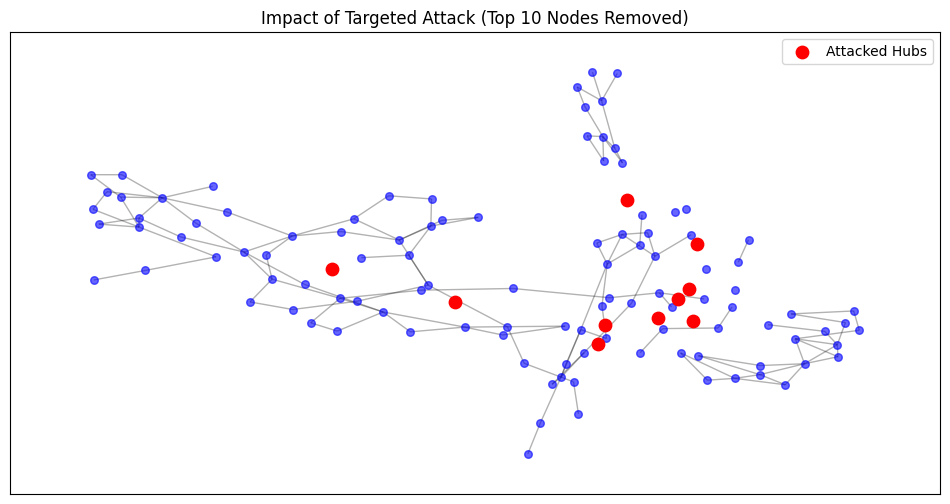

In [9]:
plt.figure(figsize=(12, 6))

pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G_shattered, pos, node_size=30, node_color='blue', alpha=0.6)
nx.draw_networkx_edges(G_shattered, pos, alpha=0.3)

removed_nodes = nodes_to_remove[:removal_steps]
nx.draw_networkx_nodes(G, pos, nodelist=removed_nodes, node_size=80, node_color='red', label='Attacked Hubs')

plt.title(f"Impact of Targeted Attack (Top {removal_steps} Nodes Removed)")
plt.legend()
plt.show()

## *Finding Bridges - edges that,if removed, disconnect the graph*

In [10]:
bridges = list(nx.bridges(G))
print(f"Number of critical bridges: {len(bridges)}")
bridge_nodes = set([n for edge in bridges for n in edge])
print(f"Nodes that are 'Single Points of Failure': {bridge_nodes}")

Number of critical bridges: 9
Nodes that are 'Single Points of Failure': {67, 70, 7, 8, 9, 72, 11, 109, 110, 111, 115, 116, 84, 85, 86}


In Network Science, the Spectral Gap (also known as Algebraic Connectivity or the Fiedler Value) is the second smallest eigenvalue of the Graph Laplacian matrix ($L$). It is defined as:$$L = D - A$$where $D$ is the Degree Matrix and $A$ is the Adjacency Matrix. If the eigenvalues are ordered as $0 = \lambda_1 \leq \lambda_2 \leq \dots \leq \lambda_n$:The Gap: The value of $\lambda_2$ represents the spectral gap.Connectivity: $\lambda_2 > 0$ if and only if the graph is connected.Robustness: A larger $\lambda_2$ indicates a more robust, "expander-like" network that is harder to disconnect. In power systems, a higher spectral gap is directly related to the synchronization stability of the grid.

In [11]:
def get_spectral_gap(graph):
    if not nx.is_connected(graph):
        return 0
    L = nx.laplacian_matrix(graph).toarray()
    evs = np.sort(np.linalg.eigvals(L))
    return evs[1].real

orig_gap = get_spectral_gap(G)
damaged_gap = get_spectral_gap(G_shattered)

print(f"Original Spectral Gap: {orig_gap:.4f}")
print(f"Damaged Spectral Gap: {damaged_gap:.4f}")

Original Spectral Gap: 0.0271
Damaged Spectral Gap: 0.0000


## *Visualising the Disconnected Graph when attacked on bridge nodes*

In [12]:

bridges = list(nx.bridges(G))
print(f"Total bridges found: {len(bridges)}")

G_minus_bridges = G.copy()
G_minus_bridges.remove_edges_from(bridges)

num_components = nx.number_connected_components(G_minus_bridges)
print(f"After removing bridges, the grid split into {num_components} disconnected islands.")

Total bridges found: 9
After removing bridges, the grid split into 10 disconnected islands.


/tmp/ipython-input-1626742865.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(components))


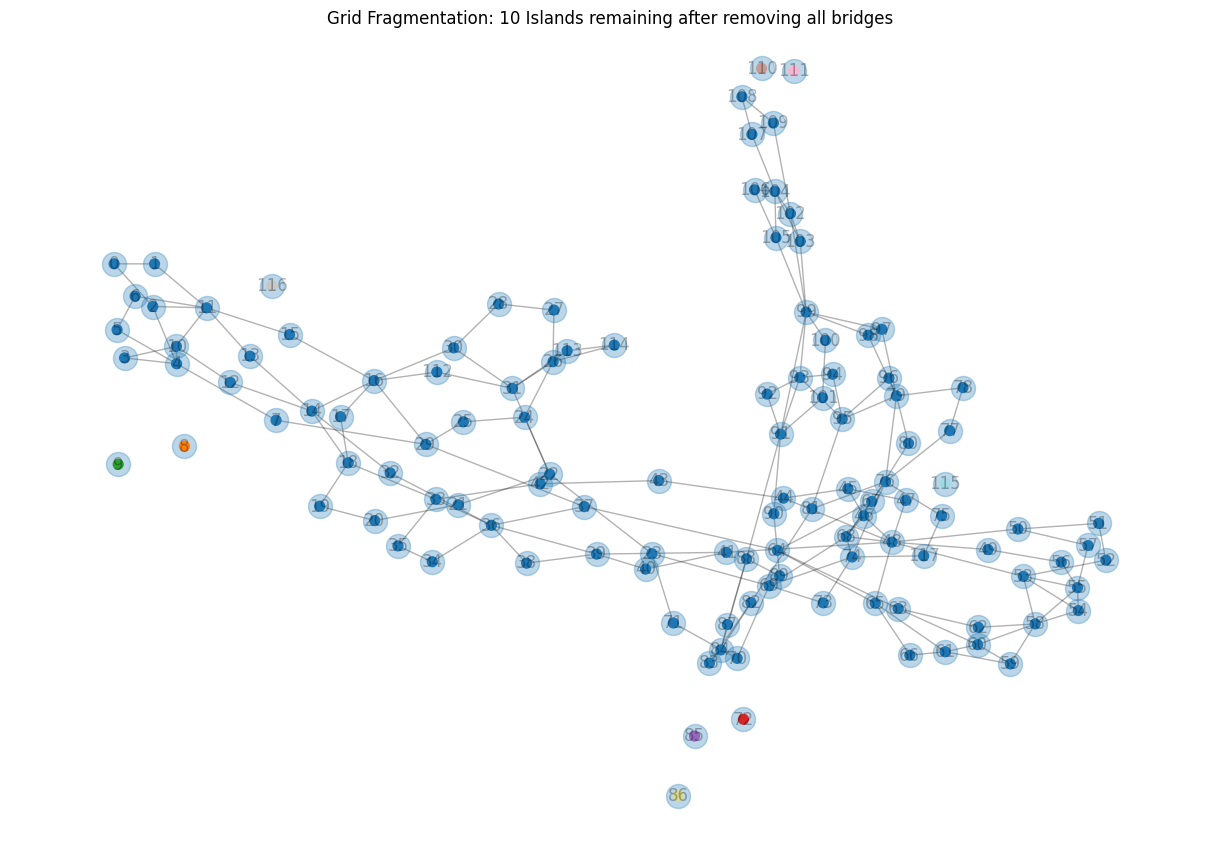

In [17]:
components = list(nx.connected_components(G_minus_bridges))

# Creating a color map for the components
colors = plt.cm.get_cmap('tab20', len(components))
node_color_map = {}
for i, component in enumerate(components):
    for node in component:
        node_color_map[node] = colors(i)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(G_minus_bridges, pos, alpha=0.3, edge_color='black',with_labels=True)

node_colors = [node_color_map[n] for n in G_minus_bridges.nodes()]
nx.draw_networkx_nodes(G_minus_bridges, pos, node_size=50, node_color=node_colors)

plt.title(f"Grid Fragmentation: {num_components} Islands remaining after removing all bridges")
plt.axis('off')
plt.show()

## *Greedy Spectral Optimization - deciding where to add a new link for maximal protection against attacks*

In [18]:
def get_algebraic_connectivity(graph):
    if not nx.is_connected(graph):
        return 0
    L = nx.laplacian_matrix(graph).toarray()
    egs = np.linalg.eigvalsh(L)
    return egs[1]

current_lambda = get_algebraic_connectivity(G)
print(f"Current Algebraic Connectivity: {current_lambda:.4f}")

non_edges = list(nx.non_edges(G))

results = []
import random
sample_non_edges = random.sample(non_edges, 500)

for u, v in sample_non_edges:
    G.add_edge(u, v)
    new_lambda = get_algebraic_connectivity(G)
    results.append(((u, v), new_lambda))
    G.remove_edge(u, v)

results.sort(key=lambda x: x[1], reverse=True)
best_edge, best_lambda = results[0]

print(f"\nOPTIMIZATION RESULT")
print(f"Best link to add: Between Node {best_edge[0]} and Node {best_edge[1]}")
print(f"New Algebraic Connectivity: {best_lambda:.4f}")
print(f"Improvement: {((best_lambda - current_lambda) / current_lambda) * 100:.2f}%")

Current Algebraic Connectivity: 0.0271

OPTIMIZATION RESULT
Best link to add: Between Node 16 and Node 103
New Algebraic Connectivity: 0.0559
Improvement: 106.03%
